In [3]:
import os
import glob
import json
import numpy as np
import pandas as pd
from pathlib import Path
from PNW_cmap import PNW_cmap
import matplotlib.pyplot as plt
from vip_slap2_analysis.utils.utils import save_figure
from vip_slap2_analysis.io.session_registry import VIPSessionRegistry
from vip_slap2_analysis.glutamate.summary import GlutamateSummary
from vip_slap2_analysis.utils.utils import normalize

import seaborn as sns
sns.set_style('white')
params = {'legend.fontsize': 'x-large',
         'axes.labelsize': 'xx-large',
         'axes.titlesize':'xx-large',
         'xtick.labelsize':'xx-large',
         'ytick.labelsize':'xx-large'}
plt.rcParams.update(params)

from IPython.display import display, HTML
display(HTML("<style>.container { width:100% !important; }</style>"))

In [4]:
%load_ext autoreload
%autoreload 2

%matplotlib notebook

In [5]:
savepath = r'C:\Users\andrew.shelton\Dropbox\allen institute\Documents\Presentations\OPhys\Data_Club\April2026\figures'

In [69]:
def _image_label_from_key(k):
    return Path(str(k).replace("\\", "/")).stem


def _safe_session_order(metadata):
    if metadata is None:
        return np.nan

    if "session_#" in metadata:
        return metadata["session_#"]

    for key in ["session_num", "session_number", "session_order"]:
        if key in metadata:
            return metadata[key]

    return np.nan


def _collapse_trials_to_amplitude(arr, amplitude_func="mean"):
    """
    Collapse an array of shape (n_trials, n_time) to one scalar per trial.
    """
    if amplitude_func == "mean":
        return np.nanmean(arr, axis=1)
    elif amplitude_func == "max":
        return np.nanmax(arr, axis=1)
    elif amplitude_func == "sum":
        return np.nansum(arr, axis=1)
    elif amplitude_func == "top10":
        k = min(10, arr.shape[1])
        part = np.partition(arr, -k, axis=1)[:, -k:]
        return np.nanmean(part, axis=1)
    else:
        raise ValueError(f"Unknown amplitude_func: {amplitude_func}")


def _compute_scalar_image_variance_metrics_for_synapse(
    image_trials_by_label,
    sample_slice=slice(50, 100),
    amplitude_func="mean",
):
    """
    For one synapse:
      1) time-average each presentation response into one scalar
      2) compute total variance across all scalar presentation responses
      3) subtract image-identity means only within matching image identities
      4) compute image-explained fraction of variance

    Returns
    -------
    dict or None
        total_var
        mean_residual_var
        mean_fve
        image_residual_var
        image_fve_total
        image_fve_by_label
        n_trials_total
        n_images_present
        grand_mean
    """
    labels = []
    amplitude_blocks = []

    for label, arr in image_trials_by_label.items():
        arr = np.asarray(arr, dtype=float)
        if arr.ndim != 2 or arr.shape[0] == 0:
            continue

        arr = arr[:, sample_slice]
        if arr.size == 0:
            continue

        amp = _collapse_trials_to_amplitude(arr, amplitude_func=amplitude_func)
        amplitude_blocks.append(amp)
        labels.extend([label] * len(amp))

    if not amplitude_blocks:
        return None

    y = np.concatenate(amplitude_blocks, axis=0)
    labels = np.asarray(labels)

    valid = np.isfinite(y)
    y = y[valid]
    labels = labels[valid]

    if y.size < 2:
        return None

    total_var = np.var(y)
    if not np.isfinite(total_var) or total_var <= 0:
        return None

    # ------------------------------------------------------------
    # Global mean subtraction on scalar amplitudes
    # This does not change variance, so mean_fve = 0 by construction.
    # We keep it explicitly for clarity.
    # ------------------------------------------------------------
    grand_mean = np.mean(y)
    mean_residual = y - grand_mean
    mean_residual_var = np.var(mean_residual)
    mean_fve = 1.0 - (mean_residual_var / total_var)

    # ------------------------------------------------------------
    # Image-identity subtraction:
    # subtract only the mean of the corresponding image identity
    # from trials belonging to that image
    # ------------------------------------------------------------
    image_residual = np.empty_like(y)
    image_fve_by_label = {}

    for lab in np.unique(labels):
        mask = labels == lab
        y_lab = y[mask]

        if y_lab.size < 1:
            image_fve_by_label[lab] = np.nan
            continue

        mu_lab = np.mean(y_lab)
        resid_lab = y_lab - mu_lab
        image_residual[mask] = resid_lab

        resid_var_lab = np.var(resid_lab)
        image_fve_by_label[lab] = 1.0 - (resid_var_lab / total_var)

    image_residual_var = np.var(image_residual)
    image_fve_total = 1.0 - (image_residual_var / total_var)

    return {
        "total_var": float(total_var),
        "mean_residual_var": float(mean_residual_var),
        "mean_fve": float(mean_fve),
        "image_residual_var": float(image_residual_var),
        "image_fve_total": float(image_fve_total),
        "image_fve_by_label": image_fve_by_label,
        "n_trials_total": int(y.size),
        "n_images_present": int(len(np.unique(labels))),
        "grand_mean": float(grand_mean),
    }


def compute_variance_decomposition_across_sessions(
    single_trial_paths,
    assets,
    act_summary,
    sample_slice=slice(50, 100),
    allowed_depths=(25, 100, 200, 250),
    amplitude_func="mean",
):
    """
    Compute scalar image-variance metrics across sessions for activated synapses.

    This version matches the user's intended method:
      - time-average each presentation first
      - compute variance across scalar presentation responses
      - subtract image-specific means only within each image identity
      - quantify image-explained variance as 1 - residual_var / total_var
    """
    activated_lookup = (
        act_summary.loc[
            (act_summary["stimulus_family"] == "image")
            & (act_summary["response_class"] == "activated") | (act_summary["response_class"] == "deactivated") | (act_summary["response_class"] == "no_change"),
            ["session_id", "dmd", "synapse_id"],
        ]
        .drop_duplicates()
    )

    activated_sets = {
        (sid, dmd): set(df["synapse_id"].tolist())
        for (sid, dmd), df in activated_lookup.groupby(["session_id", "dmd"])
    }

    all_image_labels = set()
    for path in single_trial_paths:
        data = np.load(path, allow_pickle=True)["data"][0]
        for dmd_name in ["DMD1", "DMD2"]:
            if dmd_name not in data:
                continue
            if "image_identity" not in data[dmd_name]:
                continue
            all_image_labels.update(
                _image_label_from_key(k)
                for k in data[dmd_name]["image_identity"].keys()
            )

    all_image_labels = sorted(all_image_labels)

    wide_rows = []
    long_rows = []

    for i, path in enumerate(single_trial_paths):
        asset = assets[i]
        session_id = asset.session_id
        metadata = getattr(asset, "metadata", {}) or {}

        print(f"Processing {session_id}")

        data = np.load(path, allow_pickle=True)["data"][0]

        depth_map = {
            "DMD1": metadata.get("dmd1_depth", np.nan),
            "DMD2": metadata.get("dmd2_depth", np.nan),
        }

        session_type = metadata.get("session_type", np.nan)
        session_order = _safe_session_order(metadata)

        for dmd_name in ["DMD1", "DMD2"]:
            if dmd_name not in data:
                continue
            if "image_identity" not in data[dmd_name]:
                continue

            activated_synapses = activated_sets.get((session_id, dmd_name), set())
            if len(activated_synapses) == 0:
                continue

            depth_um = depth_map[dmd_name]
            dmd_block = data[dmd_name]

            image_keys = list(dmd_block["image_identity"].keys())
            if len(image_keys) == 0:
                continue

            if "synapse_ids" in dmd_block:
                synapse_ids = np.asarray(dmd_block["synapse_ids"])
            else:
                first_im = np.asarray(dmd_block["image_identity"][image_keys[0]])
                synapse_ids = np.arange(first_im.shape[1])

            image_arrays = {
                _image_label_from_key(k): np.asarray(
                    dmd_block["image_identity"][k], dtype=float
                )
                for k in image_keys
            }

            n_synapses = next(iter(image_arrays.values())).shape[1]

            for syn_idx in range(n_synapses):
                synapse_id = synapse_ids[syn_idx]

                if synapse_id not in activated_synapses:
                    continue

                image_trials_by_label = {}
                for label, arr in image_arrays.items():
                    if syn_idx >= arr.shape[1]:
                        continue
                    image_trials_by_label[label] = arr[:, syn_idx, :]

                metrics = _compute_scalar_image_variance_metrics_for_synapse(
                    image_trials_by_label=image_trials_by_label,
                    sample_slice=sample_slice,
                    amplitude_func=amplitude_func,
                )

                if metrics is None:
                    continue

                row = {
                    "session_id": session_id,
                    "subject_id": getattr(asset, "subject_id", np.nan),
                    "dmd": dmd_name,
                    "depth_um": depth_um,
                    "session_type": session_type,
                    "session_order": session_order,
                    "synapse_id": synapse_id,
                    "synapse_index": syn_idx,
                    "n_trials_total": metrics["n_trials_total"],
                    "n_images_present": metrics["n_images_present"],
                    "total_var": metrics["total_var"],
                    "mean_residual_var": metrics["mean_residual_var"],
                    "mean_fve": metrics["mean_fve"],
                    "image_residual_var": metrics["image_residual_var"],
                    "image_fve_total": metrics["image_fve_total"],
                    "grand_mean": metrics["grand_mean"],
                }

                for lab in all_image_labels:
                    row[f"image_fve_{lab}"] = metrics["image_fve_by_label"].get(lab, np.nan)

                wide_rows.append(row)

                long_rows.append(
                    {
                        "session_id": session_id,
                        "subject_id": getattr(asset, "subject_id", np.nan),
                        "dmd": dmd_name,
                        "depth_um": depth_um,
                        "session_type": session_type,
                        "session_order": session_order,
                        "synapse_id": synapse_id,
                        "component": "mean",
                        "stimulus_label": "overall_mean",
                        "fraction": metrics["mean_fve"],
                    }
                )

                long_rows.append(
                    {
                        "session_id": session_id,
                        "subject_id": getattr(asset, "subject_id", np.nan),
                        "dmd": dmd_name,
                        "depth_um": depth_um,
                        "session_type": session_type,
                        "session_order": session_order,
                        "synapse_id": synapse_id,
                        "component": "image_total",
                        "stimulus_label": "all_images",
                        "fraction": metrics["image_fve_total"],
                    }
                )

                for lab in all_image_labels:
                    long_rows.append(
                        {
                            "session_id": session_id,
                            "subject_id": getattr(asset, "subject_id", np.nan),
                            "dmd": dmd_name,
                            "depth_um": depth_um,
                            "session_type": session_type,
                            "session_order": session_order,
                            "synapse_id": synapse_id,
                            "component": "image_by_identity",
                            "stimulus_label": lab,
                            "fraction": metrics["image_fve_by_label"].get(lab, np.nan),
                        }
                    )

    synapse_metrics_wide = pd.DataFrame(wide_rows)
    synapse_metrics_long = pd.DataFrame(long_rows)

    grouped = {
        "mean_by_depth": {},
        "image_total_by_depth": {},
        "mean_by_depth_session_type": {},
        "image_total_by_depth_session_type": {},
    }

    for depth in allowed_depths:
        sub = synapse_metrics_wide.loc[synapse_metrics_wide["depth_um"] == depth]

        grouped["mean_by_depth"][depth] = sub["mean_fve"].dropna().to_numpy()
        grouped["image_total_by_depth"][depth] = sub["image_fve_total"].dropna().to_numpy()

        grouped["mean_by_depth_session_type"][depth] = {}
        grouped["image_total_by_depth_session_type"][depth] = {}

        for sess_type, sub2 in sub.groupby("session_type", dropna=False):
            grouped["mean_by_depth_session_type"][depth][sess_type] = (
                sub2["mean_fve"].dropna().to_numpy()
            )
            grouped["image_total_by_depth_session_type"][depth][sess_type] = (
                sub2["image_fve_total"].dropna().to_numpy()
            )

    return synapse_metrics_wide, synapse_metrics_long, grouped

In [54]:
target_mice = [
    803496,
    804730,804733,810196,
    809047,803121,
    826033,838410,834788
]

registry = VIPSessionRegistry.from_basepath(
    r'\\allen\aind\scratch\ophys\Andrew\VIP_synaptic_dynamics'
)

process_df = registry.sessions(
    subject_ids=target_mice,
    exclude_session_types=["expression_check", "volume_imaging"],
    paradigms=["change_detection_passive"],
)

assets = [registry.resolve_assets(row) for _, row in process_df.iterrows()]

print(f"Loaded {len(assets)} session assets")

Loaded 56 session assets


In [70]:
st_paths = [glob.glob(os.path.join(asset.derived_dir,'**','glutamate_single_trial_df.npz'),recursive=True)[0] for asset in assets]

In [71]:
act_summary_path = r"C:\Users\andrew.shelton\Downloads\activation_summary.csv"
act_summary = pd.read_csv(act_summary_path)

In [72]:
synapse_metrics_wide, synapse_metrics_long, grouped = (
    compute_variance_decomposition_across_sessions(
        single_trial_paths=st_paths,
        assets=assets,
        act_summary=act_summary,
        sample_slice=slice(50, 100),
        amplitude_func="mean",
    )
)

Processing 803496_2025-07-25_13-02-10
Processing 803496_2025-07-28_08-04-39


C:\Users\andrew.shelton\AppData\Local\Temp\ipykernel_16752\1085092299.py:24: RuntimeWarning: Mean of empty slice
  return np.nanmean(arr, axis=1)


Processing 803496_2025-07-29_13-34-35
Processing 803496_2025-07-30_10-05-23
Processing 803496_2025-07-31_09-43-28
Processing 803496_2025-08-01_13-22-49
Processing 804730_2025-07-25_14-08-35
Processing 804730_2025-07-28_13-57-34
Processing 804730_2025-07-29_14-55-04
Processing 804730_2025-07-30_11-11-11
Processing 804730_2025-07-31_11-45-27
Processing 804730_2025-08-01_14-22-38
Processing 804733_2025-07-25_15-17-00
Processing 804733_2025-07-28_19-00-06
Processing 804733_2025-07-29_16-02-24
Processing 804733_2025-07-30_12-59-44
Processing 804733_2025-07-31_13-29-01
Processing 804733_2025-08-01_15-20-32
Processing 810196_2025-07-25_16-24-20
Processing 810196_2025-07-28_19-59-05
Processing 810196_2025-07-29_17-02-41
Processing 810196_2025-07-31_08-28-08
Processing 810196_2025-07-31_14-19-46
Processing 810196_2025-08-01_16-37-27
Processing 809047_2025-10-29_10-16-32
Processing 809047_2025-10-30_10-06-43
Processing 809047_2025-10-31_12-00-50
Processing 809047_2025-11-01_17-51-59
Processing 8

In [58]:
synapse_metrics_wide.keys()

Index(['session_id', 'subject_id', 'dmd', 'depth_um', 'session_type',
       'session_order', 'synapse_id', 'synapse_index', 'n_trials_total',
       'n_images_present', 'total_var', 'mean_residual_var', 'mean_fve',
       'image_residual_var', 'image_fve_total', 'grand_mean',
       'image_fve_100075', 'image_fve_216066', 'image_fve_268048',
       'image_fve_41006', 'image_fve_69022', 'image_fve_McGill_stairs',
       'image_fve_imk00459', 'image_fve_imk00895', 'image_fve_imk00942',
       'image_fve_imk01057', 'image_fve_imk01097', 'image_fve_imk01220',
       'image_fve_imk01306', 'image_fve_imk01333', 'image_fve_imk01378',
       'image_fve_imk01643'],
      dtype='object')

In [74]:
plot_df = synapse_metrics_wide[["depth_um",'session_id','synapse_id', "session_type", 'session_order',"mean_fve", "image_fve_total",'image_residual_var']].copy()

In [81]:
cl, cmap, cp = PNW_cmap.get_PNW_cmap('Sailboat', n_colors=4)
cp

[(0.4823529411764706, 0.7372549019607844, 0.8352941176470589),
 (0.8156862745098039, 0.8862745098039215, 0.6862745098039216),
 (0.9607843137254901, 0.8588235294117647, 0.6),
 (0.9098039215686274, 0.611764705882353, 0.5058823529411764)]

In [82]:
cp = cp[::-1]

### Plot effect of depth on image FVE overall

<IPython.core.display.Javascript object>


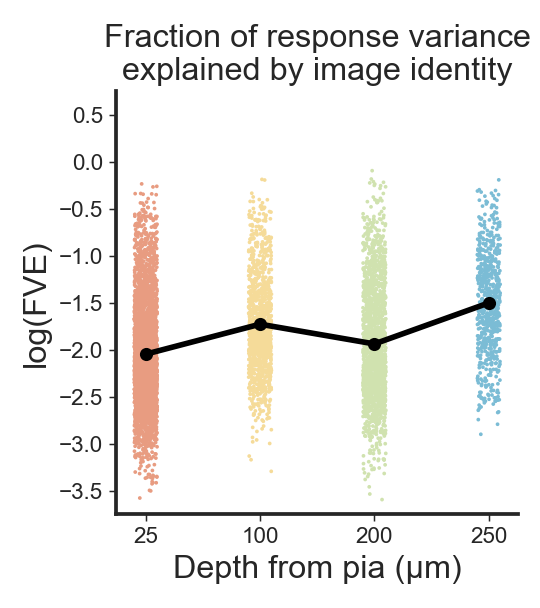

C:\Users\andrew.shelton\AppData\Local\Temp\ipykernel_16752\3942253756.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(data = plot_df,x = 'depth_um', y = np.log10(plot_df[metric]),palette=cp,size=2)


In [88]:
metric = 'image_fve_total'

fig,ax=plt.subplots(figsize=(4,4.5))

ax.tick_params(axis='x', which='major', reset=True, top=False, labelsize=12)
ax.tick_params(axis='y', which='major', reset=True, right=False, labelsize=12)

for spine in ['left','right','top','bottom']:
    ax.spines[spine].set_linewidth(2)

sns.despine()
    
sns.stripplot(data = plot_df,x = 'depth_um', y = np.log10(plot_df[metric]),palette=cp,size=2)

means = []

for depth in plot_df['depth_um'].unique():
    dft = plot_df[plot_df['depth_um']==depth]
    mean = np.nanmean(np.log10(dft[metric]))
    means.append(mean)
ax.plot(means,color='k',zorder=11,lw=3,marker='o')
ax.set_ylim(-3.75,0.75)

ax.set_ylabel('log(FVE)')
ax.set_xlabel('Depth from pia (\u03BCm)')

ax.set_title('Fraction of response variance\nexplained by image identity')

fig.tight_layout()
filen = 'Image_FVE'
# save_figure(fig,os.path.join(savepath,filen),formats = ['.pdf','.png'],dpi= 300)

### Plot effect of depth by session

In [76]:
session_df = plot_df[plot_df['session_order']>1]

<IPython.core.display.Javascript object>


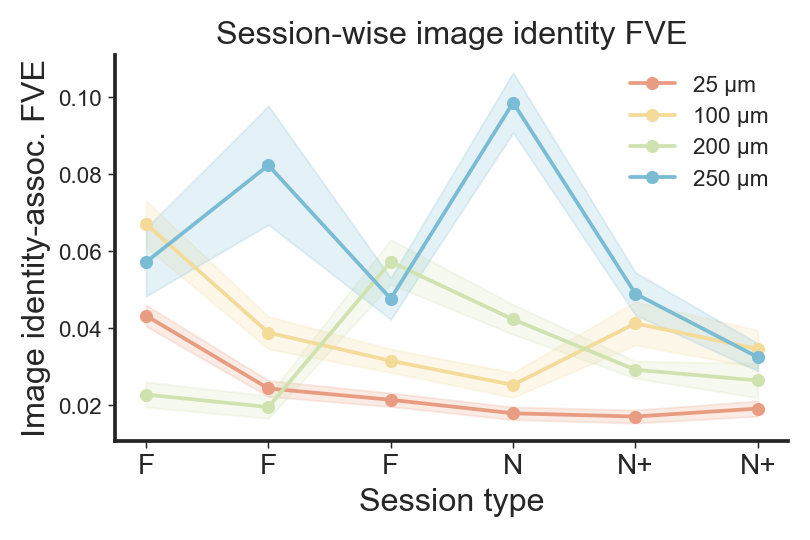

25
100
200
250


In [89]:
fig,ax = plt.subplots(figsize=(6,4))
sns.despine()
ax.tick_params(axis='x', which='major', reset=True, top=False, labelsize=12)
ax.tick_params(axis='y', which='major', reset=True, right=False, labelsize=12)
for i,depth in enumerate(session_df['depth_um'].unique()):
    print(depth)
    dft = session_df[session_df['depth_um']==depth]
    mean = []
    sem = []
    for sess in sorted(dft['session_order'].unique()):
        sess_type = dft['session_type'][dft['session_order']==sess].unique()
        
        sess_mean = np.mean(dft['image_fve_total'][dft['session_order']==sess])
        sess_sem = np.std(dft['image_fve_total'][dft['session_order']==sess])/np.sqrt(len(dft[dft['session_order']==sess]))
        
        mean.append(sess_mean)
        sem.append(sess_sem)
    ax.plot(mean,color=cp[i],lw=2,marker='o',label=f"{depth} \u03BCm")
    ax.fill_between(range(6),np.array(mean)+np.array(sem),np.array(mean)-np.array(sem),color=cp[i],alpha=0.2,zorder=0)
ax.set_xlabel('Session type')
ax.set_ylabel('Image identity-assoc. FVE')

for spine in ['left','bottom']:
    ax.spines[spine].set_linewidth(2)

ax.set_xticks(range(6))
ax.set_xticklabels(['F','F','F','N','N+','N+'],fontsize=15)
    
ax.legend(frameon=False,fontsize=12)
ax.set_title('Session-wise image identity FVE')
fig.tight_layout()

filen = 'Session_FVE'
save_figure(fig,os.path.join(savepath,filen),formats = ['.pdf','.png'],dpi= 300)

In [68]:
sem

[0.015945571010788744,
 0.02360278527862748,
 0.010106627429056622,
 0.009630276836817015,
 0.005433666740465646]

In [ ]:
import itertools
from scipy.stats import mannwhitneyu
from statsmodels.stats.multitest import multipletests


# ------------------------------------------------------------
# Pairwise depth comparisons
# ------------------------------------------------------------
depth_order = [25, 100, 200, 250]

pairwise_rows = []

for d1, d2 in itertools.combinations(depth_order, 2):
    x = plot_df.loc[plot_df["depth_um"] == d1, "image_fve_total"].dropna().to_numpy()
    y = plot_df.loc[plot_df["depth_um"] == d2, "image_fve_total"].dropna().to_numpy()

    if len(x) == 0 or len(y) == 0:
        continue

    stat, p = mannwhitneyu(x, y, alternative="two-sided")

    pairwise_rows.append(
        {
            "depth_1": d1,
            "depth_2": d2,
            "n_1": len(x),
            "n_2": len(y),
            "median_1": np.median(x),
            "median_2": np.median(y),
            "mean_1": np.mean(x),
            "mean_2": np.mean(y),
            "mw_u": stat,
            "p_uncorrected": p,
        }
    )

pairwise_stats = pd.DataFrame(pairwise_rows)

# ------------------------------------------------------------
# Multiple-comparisons correction
# ------------------------------------------------------------
reject, p_fdr, _, _ = multipletests(
    pairwise_stats["p_uncorrected"].values,
    alpha=0.05,
    method="fdr_bh",
)

pairwise_stats["p_fdr_bh"] = p_fdr
pairwise_stats["significant_fdr_bh"] = reject

pairwise_stats = pairwise_stats.sort_values("p_fdr_bh").reset_index(drop=True)

pairwise_stats

### Plot a few trials from one synapse and image to get an idea of trial-to-trial noise

In [ ]:
exmaple_session = 33
example_asset = assets[exmaple_session]
example_traces = st_paths[exmaple_session]
example_dmd = 1
example_synapse = 56

In [ ]:
traces = np.load(example_traces,allow_pickle=True)['data'][0][f'DMD{example_dmd}']['image_identity']

In [ ]:
im_names = list(traces.keys())

In [ ]:
im_colors = [
    '#c5cae9', '#ffcdd2', '#c8e6c9', '#ffe0b2',
    '#e1bee7', '#d7ccc8',
    '#9fd3f2']

In [ ]:
# ------------------------------------------------------------
# Load single-trial traces
# Assumes shape per image = (n_trials, n_synapses, n_time)
# ------------------------------------------------------------

syn_idx = 56         # synapse 56 on DMD1
n_show = 10
trial_range = 150# ~5 sequential trials per image
sample_slice = slice(0,150)   # or e.g. slice(0, 150)

image_keys = list(traces.keys())
n_images = len(image_keys)

fig, axes = plt.subplots(
    n_images, 1,
    figsize=(8, 2.2 * n_images),
    sharex=True,
    sharey=True
)



fs = 200
flash_start = 50 / fs      # 0.25 s
flash_dur = 50 / fs        # 0.25 s
gray_dur = 100 / fs        # 0.5 s
cycle_dur = flash_dur + gray_dur

if n_images == 1:
    axes = [axes]

for i,(ax, im_key) in enumerate(zip(axes, image_keys)):
    
    ax.tick_params(axis='x', which='major', reset=True, top=False, labelsize=12)
    ax.tick_params(axis='y', which='major', reset=True, right=False, labelsize=12)
    
    syn_trials = traces[im_key][trial_range:trial_range+n_show,syn_idx,:]  # (n_trials, n_synapses, n_time)
    im_label = Path(str(im_key)).stem

    trials_to_plot = np.concatenate(syn_trials)
    t = np.linspace(0,len(trials_to_plot)/fs,len(trials_to_plot))
    ax.plot(t,trials_to_plot,color='k',lw=1)
    
    for ii in range(n_show):
        start = flash_start + ii * cycle_dur
        end = start + flash_dur
        ax.axvspan(start, end, alpha=0.4, color=im_colors[i])
    
    # optional mean across shown trials
#     ax.plot(t, np.nanmean(syn_trials[:n_plot], axis=0), color="k", lw=2.5, alpha=0.9)

    ax.set_title(im_label, fontsize=11)
    ax.set_ylabel("Response")

axes[-1].set_xlabel("Time(s)")
fig.suptitle(f"Sequential image-presentation responses\nSynapse {syn_idx}, DMD{example_dmd}", y=0.99, fontsize=18)
fig.tight_layout()

In [ ]:
np.shape(traces[im_names[0]])

In [ ]:
traces[im_key][trial_range:trial_range+n_show,56,:] 